# EXPLORING MOCK DATASET

---

## Libarary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

## General

In [2]:
df = pd.read_csv("../data/data.csv")
df["event_time"] = pd.to_datetime(df["event_time"], format="ISO8601")
df["hour"]       = df["event_time"].dt.hour
df["amount"]     = df["amount"].astype(float)
df.head()

,account_id,amount,event_time,is_home,is_domestic,is_fraud,hour
0,ML_77267,1642000.0,2026-06-24 12:00:00.346336+00:00,True,True,False,12
1,ML_53653,1791000.0,2026-06-24 12:00:00.378572+00:00,True,True,False,12
2,ML_86440,2210000.0,2026-06-24 12:00:00.391866+00:00,True,True,False,12
3,ML_60756,8202000.0,2026-06-24 12:00:00.492082+00:00,True,True,False,12
4,ML_96893,648000.0,2026-06-24 12:00:01.031052+00:00,True,True,False,12


In [3]:
total = len(df)
fraud = df["is_fraud"].sum()

print(f"Total rows  : {total:,}")
print(f"Fraud rows  : {fraud:,}  ({fraud/total*100:.2f} %)")
print(f"Normal rows : {total-fraud:,}")
print(f"\nAccounts    : {df['account_id'].nunique():,}")
print(f"Time range  : {df['event_time'].min()}  →  {df['event_time'].max()}")
print(f"\nAmount stats (all):")
print(df["amount"].describe().apply(lambda x: f"{x:,.0f}"))


Total rows  : 205,787
Fraud rows  : 4,817  (2.34 %)
Normal rows : 200,970

Accounts    : 64,436
Time range  : 2026-06-24 12:00:00.346336+00:00  →  2026-06-25 11:59:59.901038+00:00

Amount stats (all):
count        205,787
mean       8,231,670
std       22,181,670
min          350,000
25%        1,118,000
50%        1,791,000
75%        6,329,000
max      945,676,000
Name: amount, dtype: str


---

## Chart

/var/folders/nj/257vyf3j1fg3pjq1zz5x_w240000gn/T/ipykernel_90565/3845059032.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="label", y="amount", ax=ax,


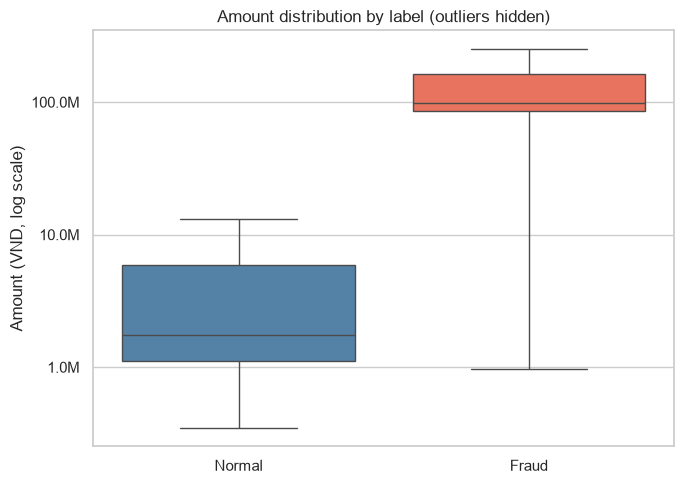

In [4]:
plot_df = df.copy()
plot_df["label"] = plot_df["is_fraud"].map({False: "Normal", True: "Fraud"})

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=plot_df, x="label", y="amount", ax=ax,
            palette={"Normal": "steelblue", "Fraud": "tomato"},
            showfliers=False)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_title("Amount distribution by label (outliers hidden)")
ax.set_xlabel("")
ax.set_ylabel("Amount (VND, log scale)")
plt.tight_layout()
plt.show()

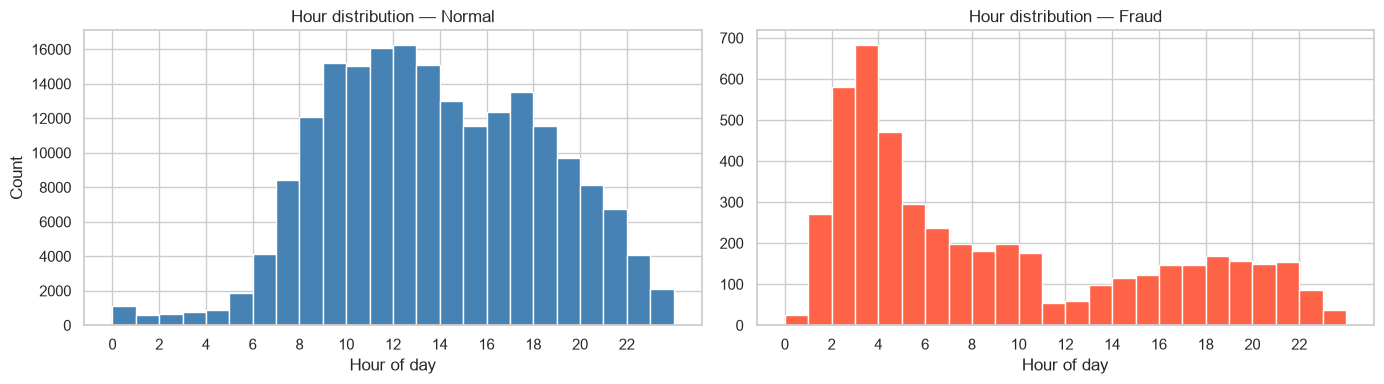

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

normal_hours = df[~df["is_fraud"]]["hour"]
fraud_hours  = df[df["is_fraud"]]["hour"]

axes[0].hist(normal_hours, bins=24, range=(0, 24), color="steelblue", edgecolor="white")
axes[0].set_title("Hour distribution — Normal")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Count")

axes[1].hist(fraud_hours, bins=24, range=(0, 24), color="tomato", edgecolor="white")
axes[1].set_title("Hour distribution — Fraud")
axes[1].set_xlabel("Hour of day")

for ax in axes:
    ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()


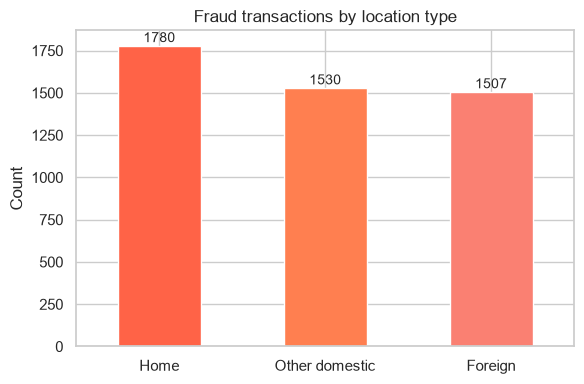

In [6]:
fraud_df = df[df["is_fraud"]].copy()
fraud_df["location_type"] = (
    fraud_df.apply(
        lambda r: "Foreign"          if not r["is_domestic"]
             else "Other domestic"   if not r["is_home"]
             else "Home",
        axis=1,
    )
)

counts = fraud_df["location_type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["tomato", "coral", "salmon"], edgecolor="white")
ax.set_title("Fraud transactions by location type")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 20, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()
